**Assignment 3: Forward Propagation and Backpropagation using TensorFlow/Keras**

In [36]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam

In [14]:
# Load the Fashion MNIST dataset

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Images Shape  :", x_test.shape)
print("Testing Labels Shape  :", y_test.shape)

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


In [15]:
# Normalize pixel values

x_train = x_train / 255.0
x_test = x_test / 255.0

print("Pixel Range after Normalization:")
print("Minimum =", x_train.min())
print("Maximum =", x_train.max())

Pixel Range after Normalization:
Minimum = 0.0
Maximum = 1.0


In [16]:
# Define class names

class_names = [
    'T-shirt/Top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

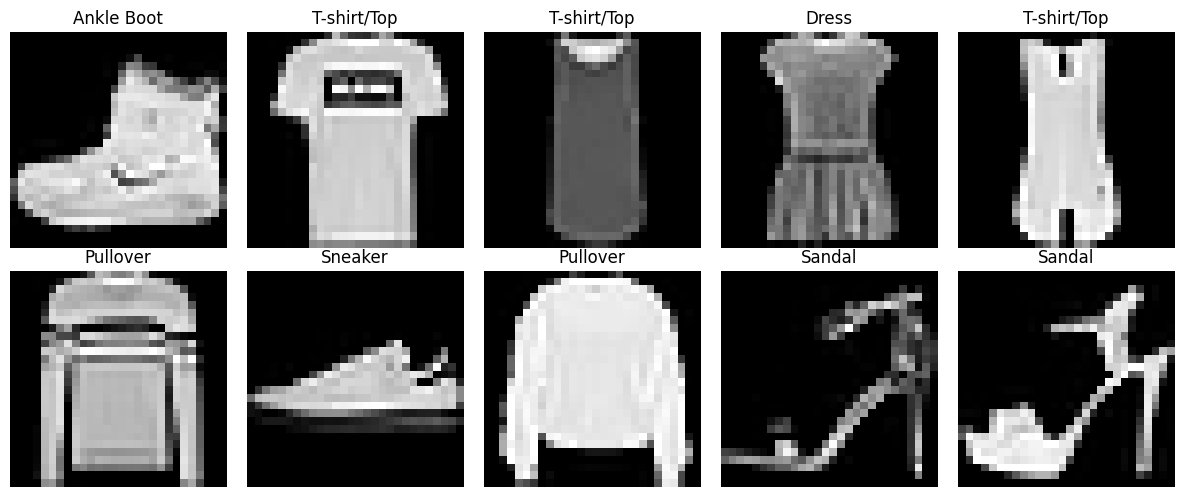

In [19]:
# Display the first 10 sample images

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [20]:
# Function to create the MLP model

def create_model(learning_rate):

    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [21]:
# Learning rates to compare

learning_rates = [0.0001, 0.001, 0.01]

# Store results
lr_accuracy = []
lr_loss = []

In [22]:
# Train the model with different learning rates

for lr in learning_rates:

    print("=" * 50)
    print(f"Training Model with Learning Rate = {lr}")

    model = create_model(lr)

    history = model.fit(
        x_train,
        y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

    lr_accuracy.append(test_accuracy)
    lr_loss.append(test_loss)

    print(f"Test Accuracy : {test_accuracy:.4f}")
    print(f"Test Loss     : {test_loss:.4f}")

Training Model with Learning Rate = 0.0001
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7654 - loss: 0.7264 - val_accuracy: 0.8266 - val_loss: 0.5054
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8400 - loss: 0.4654 - val_accuracy: 0.8455 - val_loss: 0.4426
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8548 - loss: 0.4185 - val_accuracy: 0.8536 - val_loss: 0.4189
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8641 - loss: 0.3918 - val_accuracy: 0.8627 - val_loss: 0.3964
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8691 - loss: 0.3731 - val_accuracy: 0.8668 - val_loss: 0.3813
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8742 - loss: 0.3580 - val_accuracy: 0.8577 - val_loss: 0.3950
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8789 - loss: 0.3461 - val_accuracy: 0.8702 - val_loss: 0.3682
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8811 - loss: 0.3359 - val_accurac

In [23]:
print("\nComparison of Learning Rates")

print("-" * 45)
print("Learning Rate\tAccuracy\tLoss")
print("-" * 45)

for lr, acc, loss in zip(learning_rates, lr_accuracy, lr_loss):
    print(f"{lr}\t\t{acc:.4f}\t\t{loss:.4f}")


Comparison of Learning Rates
---------------------------------------------
Learning Rate	Accuracy	Loss
---------------------------------------------
0.0001		0.8698		0.3694
0.001		0.8735		0.3665
0.01		0.8466		0.4862


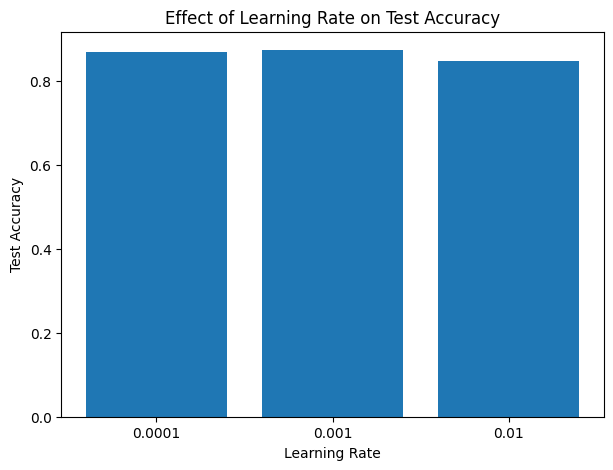

In [24]:
plt.figure(figsize=(7,5))

plt.bar(
    ['0.0001', '0.001', '0.01'],
    lr_accuracy
)

plt.title("Effect of Learning Rate on Test Accuracy")
plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")

plt.show()

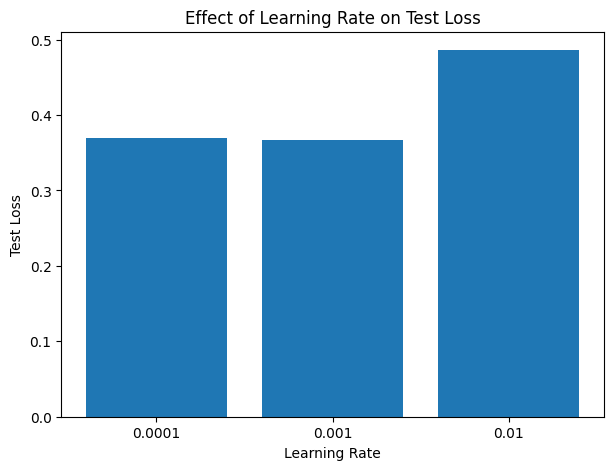

In [25]:
plt.figure(figsize=(7,5))

plt.bar(
    ['0.0001', '0.001', '0.01'],
    lr_loss
)

plt.title("Effect of Learning Rate on Test Loss")
plt.xlabel("Learning Rate")
plt.ylabel("Test Loss")

plt.show()

In [26]:
# Different epoch values to compare

epochs_list = [5, 10, 20]

epoch_accuracy = []
epoch_loss = []

In [27]:
# Fixed learning rate
learning_rate = 0.001

for epochs in epochs_list:

    print("=" * 50)
    print(f"Training Model for {epochs} Epochs")

    model = create_model(learning_rate)

    history = model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    epoch_accuracy.append(test_accuracy)
    epoch_loss.append(test_loss)

    print(f"Test Accuracy : {test_accuracy:.4f}")
    print(f"Test Loss     : {test_loss:.4f}")

Training Model for 5 Epochs
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8156 - loss: 0.5215 - val_accuracy: 0.8597 - val_loss: 0.3897
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8651 - loss: 0.3781 - val_accuracy: 0.8652 - val_loss: 0.3699
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8763 - loss: 0.3400 - val_accuracy: 0.8650 - val_loss: 0.3602
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8813 - loss: 0.3173 - val_accuracy: 0.8792 - val_loss: 0.3325
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8893 - loss: 0.2986 - val_accuracy: 0.8841 - val_loss: 0.3326
Test Accuracy : 0.8707
Test Loss     : 0.3598
Training Model for 10 Epochs
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8156 - loss: 0.5185 - val_accuracy: 0.8547 - val_loss: 0.3983
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8609 - loss: 0.3830 - val_accuracy: 0.8598 - val_loss:

In [28]:
print("\nComparison of Different Epochs")

print("-"*40)
print("Epochs\tAccuracy\tLoss")
print("-"*40)

for ep, acc, loss in zip(epochs_list, epoch_accuracy, epoch_loss):
    print(f"{ep}\t{acc:.4f}\t\t{loss:.4f}")


Comparison of Different Epochs
----------------------------------------
Epochs	Accuracy	Loss
----------------------------------------
5	0.8707		0.3598
10	0.8724		0.3716
20	0.8806		0.4033


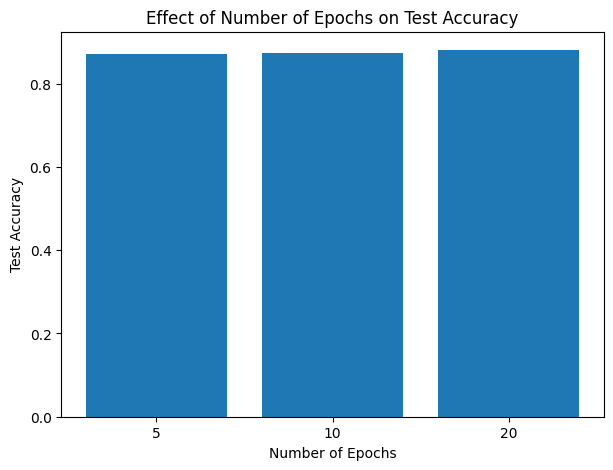

In [29]:
plt.figure(figsize=(7,5))

plt.bar(
    ['5', '10', '20'],
    epoch_accuracy
)

plt.title("Effect of Number of Epochs on Test Accuracy")
plt.xlabel("Number of Epochs")
plt.ylabel("Test Accuracy")

plt.show()

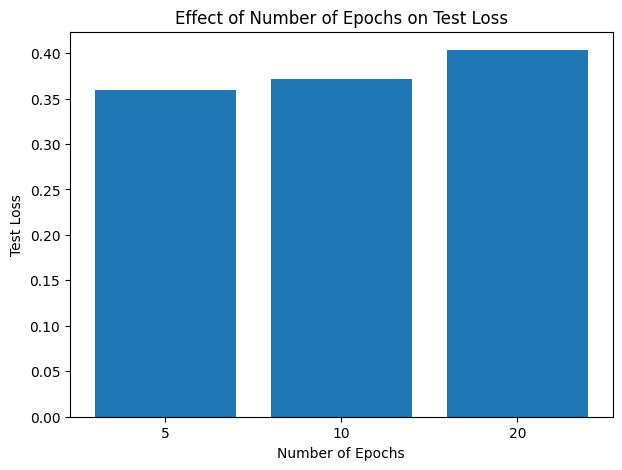

In [30]:
plt.figure(figsize=(7,5))

plt.bar(
    ['5', '10', '20'],
    epoch_loss
)

plt.title("Effect of Number of Epochs on Test Loss")
plt.xlabel("Number of Epochs")
plt.ylabel("Test Loss")

plt.show()

In [32]:
# Training the best model

best_model = create_model(0.001)

history = best_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8189 - loss: 0.5105 - val_accuracy: 0.8621 - val_loss: 0.3966
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8624 - loss: 0.3790 - val_accuracy: 0.8669 - val_loss: 0.3665
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8743 - loss: 0.3408 - val_accuracy: 0.8801 - val_loss: 0.3389
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8826 - loss: 0.3140 - val_accuracy: 0.8815 - val_loss: 0.3377
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8891 - loss: 0.2971 - val_accuracy: 0.8802 - val_loss: 0.3265
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8946 - loss: 0.2815 - val_accuracy: 0.8771 - val_loss: 0.3490
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8989 - loss: 0.2692 - val_accuracy: 0.8796 - val_loss: 0.3309
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9030 - loss: 0.2589 - 

In [33]:
test_loss, test_accuracy = best_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Best Model Test Accuracy : {test_accuracy:.4f}")
print(f"Best Model Test Loss     : {test_loss:.4f}")

Best Model Test Accuracy : 0.8832
Best Model Test Loss     : 0.3916


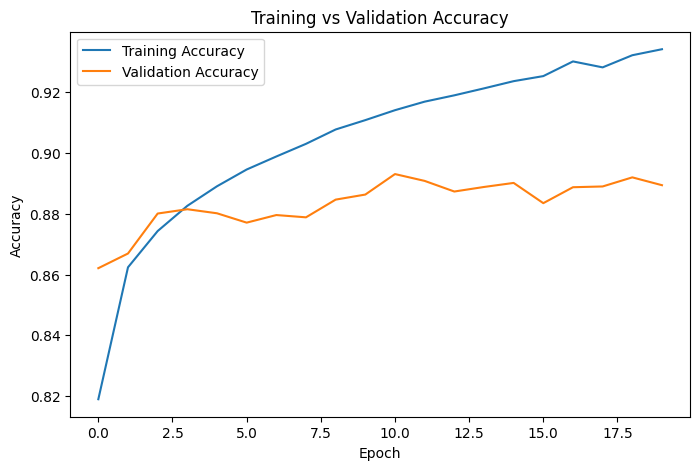

In [34]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

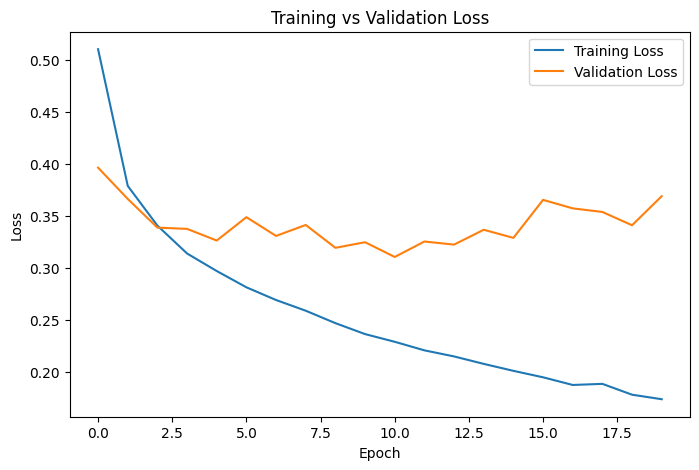

In [35]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [37]:
# Learning Rate Results

lr_results = pd.DataFrame({
    'Learning Rate': learning_rates,
    'Test Accuracy': [round(acc, 4) for acc in lr_accuracy],
    'Test Loss': [round(loss, 4) for loss in lr_loss]
})

print("Learning Rate Comparison")
display(lr_results)

Learning Rate Comparison


,Learning Rate,Test Accuracy,Test Loss
0,0.0001,0.8698,0.3694
1,0.0010,0.8735,0.3665
2,0.0100,0.8466,0.4862


In [38]:
# Epoch Results

epoch_results = pd.DataFrame({
    'Epochs': epochs_list,
    'Test Accuracy': [round(acc, 4) for acc in epoch_accuracy],
    'Test Loss': [round(loss, 4) for loss in epoch_loss]
})

print("Epoch Comparison")
display(epoch_results)

Epoch Comparison


,Epochs,Test Accuracy,Test Loss
0,5,0.8707,0.3598
1,10,0.8724,0.3716
2,20,0.8806,0.4033
